In [1]:
# magic commands
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
# imports
import os
import sys
import numpy as np
from sklearn.metrics import adjusted_mutual_info_score as ami
from sklearn.metrics import adjusted_rand_score as ari
sys.path.append("/export/share/peters57dm/Verbund/deepsync/experiments/")
from helper.datasets import (
    load_pendigits,
    load_optdigits,
    load_letterrecognition,
    load_gaussian_blobs,
    load_example,
    load_usps,
    load_htru,
    load_har,
    load_mice,
    load_synth_high,
    load_synth_low,
    load_mnist,
    load_fmnist,
    load_cifar10,
    load_coil20,
    load_coil100,
    load_cifar100,
    load_weizmann,
    load_letterrecognition,
    load_data,
    data_path,
)
from helper.deep import (
    detect_device,
    encode_batchwise,
    get_train_and_testloader,
    load_pretrained_model,
)
from helper.utils import load_json_as_dict
from helper.deep import (
    Autoencoder,
    get_train_and_testloader,
    detect_device,
    load_pretrained_model,
    encode_batchwise,
)
sys.path.append("/export/share/peters57dm/Verbund/deepsync/")
from DeepSynC.helper import get_local_core_points

from SHiP import SHiP
from SHiP.ultrametric_tree import UltrametricTreeType as UTreeType, AVAILABLE_ULTRAMETRIC_TREE_TYPES
from SHiP.partitioning import PartitioningMethod as PMethod, AVAILABLE_PARTITIONING_METHODS


In [3]:
max_embed_size = 10
batch_size = 256
pretrianed_models_root_path = "/export/share/peters57dm/Verbund/deepsync/experiments/comparison102/ae_sync_loss/knn_label_assignment"
exp_no_name = "exp_00"
k = 50
percent = 0.1
device = detect_device()

In [4]:
data, gt_labels, data_name = load_data(loading_method=load_example)
core_pts_path = os.path.join(data_path, 'corepts', f'{data_name}_corepts.npy')
embedded_space_dim = min(data.shape[1], max_embed_size)
model = Autoencoder(input_dim=data.shape[1], embedding_size=embedded_space_dim)
trainloader, testloader = get_train_and_testloader(data, gt_labels, batch_size)
pretrained_model_path = os.path.join(pretrianed_models_root_path, data_name, exp_no_name, 'pretrained_autoencoder.pth')
model = load_pretrained_model(model, pretrained_model_path, device)
embedded, gt_labels = encode_batchwise(testloader, model, device)
core_points_mask, _ = get_local_core_points(embedded, k, percent, core_pts_path)

/export/share/peters57dm/Verbund/deepsync/helper.py:670: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(pretrained_model_path, map_location=device)


In [15]:
X = embedded[np.where(np.diag(core_points_mask)==1)[0]]
true_labels = gt_labels[np.where(np.diag(core_points_mask)==1)[0]]
treeType = UTreeType.DCTree
power = 2  # or try 1
partitioningMethod = PMethod.ElbowOld
# partitioningMethod = PMethod.MedianOfElbow
# partitioningMethod = PMethod.MeanOfElbow

config = {
#    "min_points": 5,
#    "min_cluster_size": 15,
#    "optimize_tree": True,  # standardize_tree, better name?
}

ship = SHiP(data=X, treeType=treeType, config=config)

labels = ship.fit_predict(power, partitioningMethod)

In [16]:
ami(true_labels, labels)

0.9369656480432678

In [17]:
ari(true_labels, labels)

0.8965931126804496

# save the results

In [20]:
import os
import json
import sys
import openpyxl
from openpyxl.styles import PatternFill
from openpyxl.utils import get_column_letter

def get_color_fill(value):
    if value > 0.95:
        return PatternFill(start_color='00FF00', end_color='00FF00', fill_type='solid')  # Green
    elif value < 0.5:
        return PatternFill(start_color='FF0000', end_color='FF0000', fill_type='solid')  # Red
    elif value < 0.8:
        return PatternFill(start_color='FFA500', end_color='FFA500', fill_type='solid')  # Orange
    elif value < 0.9:
        return PatternFill(start_color='FFFF00', end_color='FFFF00', fill_type='solid')  # Yellow
    return None

def process_json_files(directory):
    results = []

    for filename in os.listdir(directory):
        if filename.endswith('_results.json'):
            dataset_name = filename.replace('_results.json', '')
            file_path = os.path.join(directory, filename)
            with open(file_path, 'r') as f:
                data = json.load(f)
                ami = data.get('AMI')
                ari = data.get('ARI')
                results.append((dataset_name, ami, ari))

    return results

def save_to_excel(results, output_path='results.xlsx'):
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Results"

    # Headers
    ws.append(["Dataset", "AMI", "ARI"])

    for row in results:
        ws.append(row)

    # Apply coloring
    for i, row in enumerate(results, start=2):  # start=2 because of header
        ami_fill = get_color_fill(row[1])
        ari_fill = get_color_fill(row[2])
        if ami_fill:
            ws[f'B{i}'].fill = ami_fill
        if ari_fill:
            ws[f'C{i}'].fill = ari_fill

    wb.save(output_path)
    print(f"Saved results to {output_path}")

In [22]:
dir_path = "/export/share/peters57dm/Verbund/deepsync/experiments/SHiP_CorePoints_Clustering"
if not os.path.isdir(dir_path):
    print(f"Error: {dir_path} is not a valid directory.")
    sys.exit(1)

results = process_json_files(dir_path)
save_to_excel(results, os.path.join(
    dir_path, "SHiP_corepts_results_summary.xlsx"
))

Saved results to /export/share/peters57dm/Verbund/deepsync/experiments/SHiP_CorePoints_Clustering/SHiP_corepts_results_summary.xlsx


Files already downloaded and verified
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6914983..2.0670013].


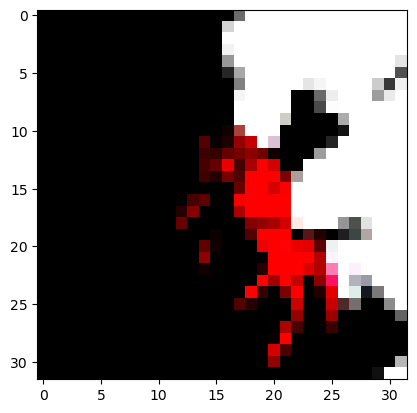

In [ ]:
from matplotlib import pyplot as plt
from clustpy.data import load_cifar100 as clustpy_load_cifar100
cldata, labels = clustpy_load_cifar100(return_X_y=True, downloads_path=data_path)
cldata = np.reshape(data,(data.shape[0],32,32,3))
plt.imshow(cldata[150])

In [42]:
import torch

In [ ]:
data, gt_labels, data_name = load_data(load_cifar100)

Files already downloaded and verified
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6914983..2.0670013].


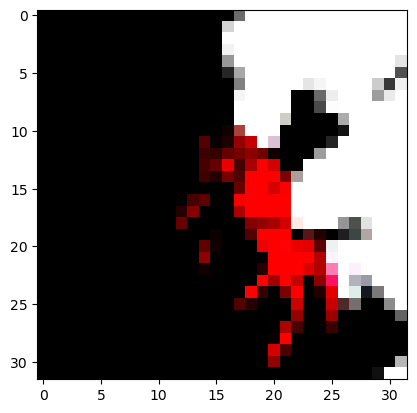

In [48]:
data = torch.reshape(data,(data.shape[0],32,32,3))
data = torch.permute(data,(0,1,2,3))
plt.imshow(data[150])

In [ ]:
from clustpy.data import load_mnist, load_gtsrb, load_fmnist, load_optdigits, load_usps
from clustpy.data.preprocessing import ZNormalizer
import numpy as np
data_path = "/export/share/peters57dm/Verbund/data/benchmark"

data, labels = load_mnist(return_X_y=True, downloads_path=data_path)
norm = ZNormalizer(False)
normalized_data = norm.fit_transform(data)

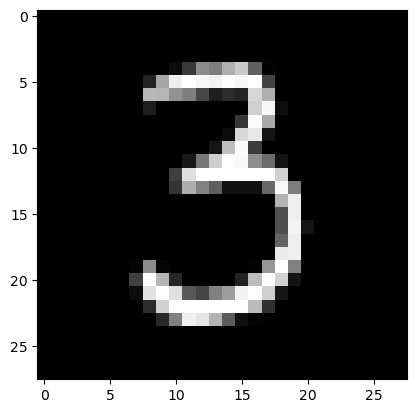

In [33]:
import matplotlib.pyplot as plt
plt.imshow(normalized_data[50].reshape((28, 28)), cmap='gray')

In [9]:
data, labels = load_gtsrb(return_X_y=True, downloads_path=data_path)

In [ ]:
# data = np.reshape(data,(data.shape[0],32,32,3))
data = np.moveaxis(data,(0,1,2,3), (0,2,3,1))

AttributeError: module 'numpy' has no attribute 'permute_dims'

In [ ]:
from clustpy.data.preprocessing import ZNormalizer
# grayscale = False
# tabular or RGB = True
norm = ZNormalizer()

In [ ]:
def get_high_cof_labels(prediction_matrix, n, crop):
    cols_to_check = prediction_matrix
    if crop is not None:
        cols_to_check = prediction_matrix[:, -n:]
    else : # iteration number < n_check
        # initialize with all zeros
        high_confidence_labels = np.zeros(prediction_matrix.shape[0], dtype=bool)
        # all labeled points are high confidence labels
        high_confidence_labels[cols_to_check[:, 0] >= 0] = True 
        return high_confidence_labels
    i = 0
    all_equal = cols_to_check[:, i] == cols_to_check[:, i+1]
    while i+1 < cols_to_check.shape[1]:
        check = cols_to_check[:, i] == cols_to_check[:, i+1]
        all_equal = np.logical_and(all_equal, check)
        i += 1
    custom_labels_mask = prediction_matrix[:, -2] < 0
    all_equal[custom_labels_mask] = False
    return all_equal

In [101]:
import numpy as np
n_check = 3
training_iterations = 10
prediction_matrix = np.array(
    [
        [0],
        [1],
        [-1]
    ]
)

In [103]:
i = 0
if i >= n_check:
    crop = i
else :
    crop = None
high_confidence_labels = get_high_cof_labels(
            prediction_matrix,
            n_check,
            crop
        )
high_confidence_labels

array([ True,  True, False])

In [60]:
np.zeros((3, 2))

array([[0., 0.],
       [0., 0.],
       [0., 0.]])